# Single-CW Evolution: Mode-Breaking Heatmap

**Question**: For what SMBH binary parameters does a single CW break the pulsar-distance
mode degeneracy through frequency evolution?

**Key quantity**: `N_corr = f_gw / (|f_dot| * T_span)`

- `N_corr >> 1`: CW is monochromatic over `T_span` → pulsar-term modes degenerate
- `N_corr << 1`: frequency evolves substantially → phase-connected template selects
  the correct distance → mode degeneracy broken

**Structure**:
| Part | Content |
|------|---------|
| **A** | Analytic 50×50 heatmap of N_corr and hc over (log10_Mc, log10_fgw) |
| **B** | Likelihood validation at 6 representative grid points |
| **C** | Summary: measured delta_lnL scattered on N_corr map |

In [43]:
import sys, importlib
sys.path.insert(0, "../CW_lnL_check")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import time
from pathlib import Path

import cw_helpers as cwh
importlib.reload(cwh)
from cw_helpers import (
    load_pulsars, inject_noisefree_cw, build_noisefree_likelihood,
    scan_pulsar_distance, analyze_peaks, compute_mode_spacing,
)

# ── Physical constants ────────────────────────────────────────────────────────
MSUN_GEOM = 4.925490947e-6    # G*Msun/c^3  [seconds]
TSPAN     = 15 * 365.25 * 86400  # 15 yr  [seconds]
C_LIGHT   = 3e8               # m/s
D_100MPC_S = 100 * 3.086e22 / C_LIGHT  # 100 Mpc in light-seconds

print(f"T_span   = {TSPAN:.3e} s  ({TSPAN/3.156e7:.1f} yr)")
print(f"D_100Mpc = {D_100MPC_S:.3e} s")



T_span   = 4.734e+08 s  (15.0 yr)
D_100Mpc = 1.029e+16 s


## Part A — Analytic heatmap

Compute `N_corr` and `hc` on a 50×50 grid.
- `f_dot = (96/5) π^(8/3) (G Mc/c³)^(5/3) f_gw^(11/3)` — Peters (1964) inspiral
- `N_corr = f_gw / (|f_dot| T_span)` — modes correlated per observation
- `hc = 4 Mc_geom^(5/3) (π f_gw)^(2/3) / D_geom` — peak GW strain at 100 Mpc

In [44]:
# 50x50 grid
log10_Mc_arr  = np.linspace(8.0, 11.0, 50)   # log10(Mc/Msun)
log10_fgw_arr = np.linspace(-8.5, -7.0, 50)  # log10(fgw/Hz)

# Meshgrid: rows=Mc, cols=fgw
fgw_grid, Mc_grid = np.meshgrid(log10_fgw_arr, log10_Mc_arr)
fgw     = 10.0**fgw_grid
Mc_geom = MSUN_GEOM * 10.0**Mc_grid   # [seconds]

# Frequency derivative (circular inspiral)
f_dot = (96.0/5.0) * np.pi**(8.0/3.0) * Mc_geom**(5.0/3.0) * fgw**(11.0/3.0)

# Number of correlated distance modes
# N_corr >> 1 => monochromatic (many degenerate modes)
# N_corr << 1 => evolving (mode degeneracy broken)
N_corr = fgw / (np.abs(f_dot) * TSPAN)

# Peak GW strain at 100 Mpc (circular binary, h0)
# h0 = 4 * Mc_geom^(5/3) * (pi*fgw)^(2/3) / D_geom  [dimensionless]
hc = 4.0 * Mc_geom**(5.0/3.0) * (np.pi * fgw)**(2.0/3.0) / D_100MPC_S

N_corr_grid = N_corr
hc_grid = hc

print(f"N_corr range:  [{N_corr.min():.2e}, {N_corr.max():.2e}]")
print(f"log10(N_corr): [{np.log10(N_corr).min():.2f}, {np.log10(N_corr).max():.2f}]")
print(f"hc range (100 Mpc): [{hc.min():.2e}, {hc.max():.2e}]")
print(f"log10(hc):     [{np.log10(hc).min():.2f}, {np.log10(hc).max():.2f}]")


N_corr range:  [7.85e-03, 7.85e+06]
log10(N_corr): [-2.10, 6.90]
hc range (100 Mpc): [5.52e-17, 5.52e-11]
log10(hc):     [-16.26, -10.26]


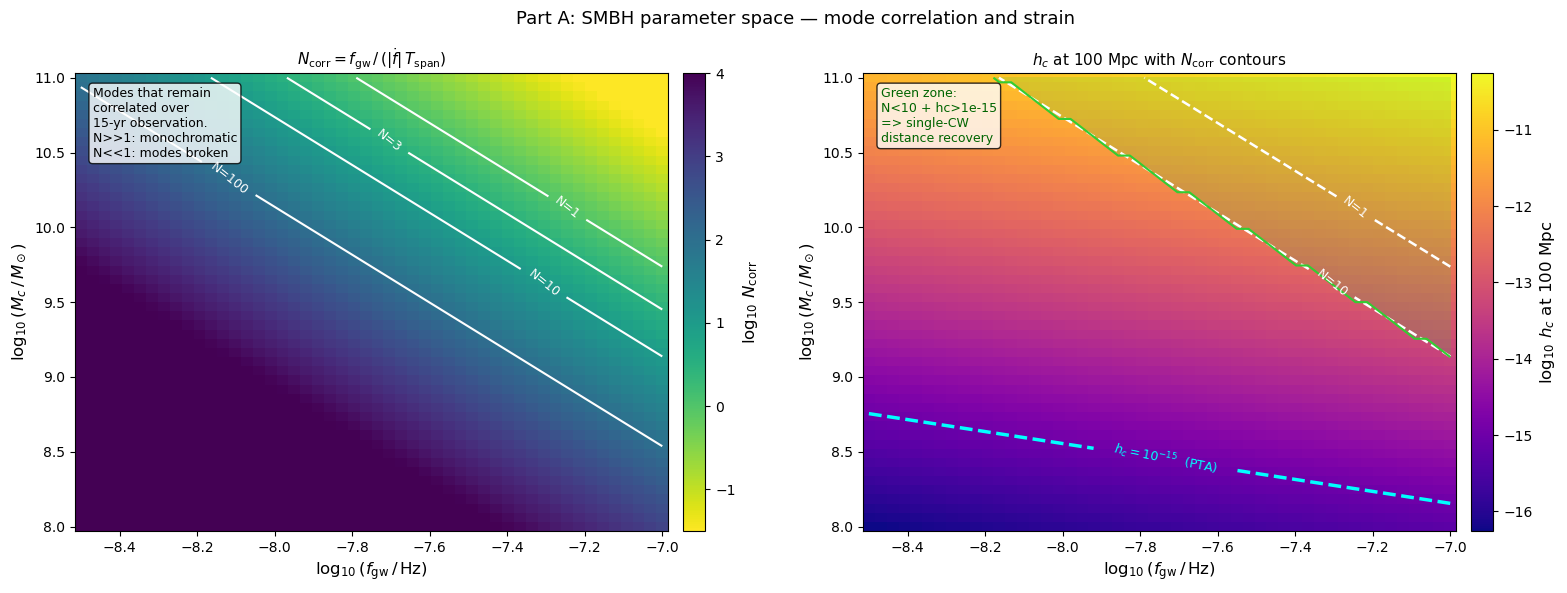

Saved: 01c_part_A_heatmap.pdf


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Part A: SMBH parameter space — mode correlation and strain", fontsize=13)

# ── Panel 1: log10(N_corr) ────────────────────────────────────────────────────
ax = axes[0]
pcm1 = ax.pcolormesh(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                      cmap="viridis_r", shading="auto",
                      vmin=-1.5, vmax=4.0)
cb1 = plt.colorbar(pcm1, ax=ax, pad=0.02)
cb1.set_label(r"$\log_{10}\,N_{\mathrm{corr}}$", fontsize=12)

# Contours at N_corr = 1, 3, 10, 100
nc_levels = [0.0, np.log10(3), 1.0, 2.0]
cs1 = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                  levels=nc_levels, colors="white", linewidths=1.5)
label_map = dict(zip(cs1.levels, ["N=1", "N=3", "N=10", "N=100"]))
ax.clabel(cs1, fmt=label_map, fontsize=9, inline=True)

ax.set_xlabel(r"$\log_{10}(f_{\rm gw}\,/\,{\rm Hz})$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(M_c\,/\,M_\odot)$", fontsize=12)
ax.set_title(r"$N_{\mathrm{corr}} = f_{\rm gw}\,/\,(|\dot{f}|\,T_{\rm span})$", fontsize=11)
ax.text(0.03, 0.97,
        "Modes that remain\ncorrelated over\n15-yr observation.\nN>>1: monochromatic\nN<<1: modes broken",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(fc="white", alpha=0.8, boxstyle="round,pad=0.3"))

# ── Panel 2: log10(hc) + N_corr contours + zone ──────────────────────────────
ax = axes[1]
pcm2 = ax.pcolormesh(log10_fgw_arr, log10_Mc_arr, np.log10(hc_grid),
                      cmap="plasma", shading="auto")
cb2 = plt.colorbar(pcm2, ax=ax, pad=0.02)
cb2.set_label(r"$\log_{10}\,h_c$ at 100 Mpc", fontsize=12)

# N_corr = 1 and N_corr = 10 as white dashed
cs2 = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                  levels=[0.0, 1.0], colors="white",
                  linestyles="--", linewidths=1.8)
label_map2 = dict(zip(cs2.levels, ["N=1", "N=10"]))
ax.clabel(cs2, fmt=label_map2, fontsize=9, inline=True)

# PTA sensitivity: hc ~ 1e-15
cs_pta = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(hc_grid),
                     levels=[-15.0], colors="cyan", linewidths=2.5)
ax.clabel(cs_pta, fmt={-15.0: r"$h_c=10^{-15}$  (PTA)"}, fontsize=9, inline=True)

# Shade the "distance recovery zone": N_corr < 10 AND hc > 1e-15
zone = (N_corr_grid < 10) & (hc_grid > 1e-15)
ax.contourf(log10_fgw_arr, log10_Mc_arr, zone.astype(float),
            levels=[0.5, 1.5], colors=["limegreen"], alpha=0.18)
ax.contour(log10_fgw_arr, log10_Mc_arr, zone.astype(float),
           levels=[0.5], colors=["limegreen"], linewidths=1.5)
ax.text(0.03, 0.97,
        "Green zone:\nN<10 + hc>1e-15\n=> single-CW\ndistance recovery",
        transform=ax.transAxes, va="top", fontsize=9, color="darkgreen",
        bbox=dict(fc="white", alpha=0.8, boxstyle="round,pad=0.3"))

ax.set_xlabel(r"$\log_{10}(f_{\rm gw}\,/\,{\rm Hz})$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(M_c\,/\,M_\odot)$", fontsize=12)
ax.set_title(r"$h_c$ at 100 Mpc with $N_{\rm corr}$ contours", fontsize=11)

plt.tight_layout()
plt.savefig("01c_part_A_heatmap.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_A_heatmap.pdf")


## Part B — Likelihood validation

Six representative points spanning the N_corr transition.
For each: inject CW, build noise-free likelihood, 1D distance scan on widest-prior pulsar.

In [46]:
N_PSR = 80  # discovery global-GP path currently fails for >100 pulsars
_all_ent_psrs, _all_disco_psrs = load_pulsars(None)

# Keep enterprise/discovery arrays aligned while selecting best EM distance priors.
psr_pairs_by_sigma = sorted(
    zip(_all_ent_psrs, _all_disco_psrs),
    key=lambda pair: pair[1].pdist[1],
)
selected_pairs = psr_pairs_by_sigma[:N_PSR]
ent_psrs = [pair[0] for pair in selected_pairs]
disco_psrs = [pair[1] for pair in selected_pairs]
sorted_psrs = disco_psrs
target_psr = sorted_psrs[-1]  # widest prior among selected pulsars

print(f"Loaded {len(_all_disco_psrs)} pulsars total.")
print(f"Selected {len(disco_psrs)} pulsars with tightest EM distance priors.")
print("Selected pulsars by prior sigma (target = widest selected):")
for psr in sorted_psrs:
    marker = " <-- TARGET" if psr is target_psr else ""
    print(f"  {psr.name:20s}  mu={psr.pdist[0]:.3f}  sigma={psr.pdist[1]:.3f} kpc{marker}")

# Base CW sky position + orientation (same for all validation points)
BASE_CW = {"cos_gwtheta": 0.3, "gwphi": 2.5, "cos_inc": -0.2,
            "phase0": 1.0, "psi": 0.7, "log10_h": -12.0,
            "log10_mc": 9.0, "log10_fgw": -8.0}  # overridden below

# 6 validation points spanning the N_corr transition
VALIDATION_POINTS = [
    {"label": "A", "log10_Mc":  9.0,  "log10_fgw": -8.0,  "desc": "N>>100, no evol"},
    {"label": "B", "log10_Mc": 10.0,  "log10_fgw": -8.0,  "desc": "N~100, weak evol"},
    {"label": "C", "log10_Mc":  9.0,  "log10_fgw": -7.0,  "desc": "N~10,  mod evol"},
    {"label": "D", "log10_Mc": 10.0,  "log10_fgw": -7.0,  "desc": "N<1,  strong evol"},
    {"label": "E", "log10_Mc": 11.0,  "log10_fgw": -7.0,  "desc": "N<<1, extreme evol"},
    {"label": "F", "log10_Mc":  9.699,"log10_fgw": -7.523, "desc": "Mc=5e9, f=3e-8 (realistic)"},
]

# Pre-compute analytic N_corr for each point
print(f"\n{'Label':6s}  {'log10_Mc':>9}  {'log10_fgw':>10}  {'N_corr':>10}  Description")
print("-" * 68)
for vp in VALIDATION_POINTS:
    Mc_g = MSUN_GEOM * 10**vp["log10_Mc"]
    fgw  = 10**vp["log10_fgw"]
    fdot = (96/5) * np.pi**(8/3) * Mc_g**(5/3) * fgw**(11/3)
    Nc   = fgw / (abs(fdot) * TSPAN)
    vp["N_corr_analytic"] = Nc
    vp["f_dot"] = fdot
    print(f"  {vp['label']:4s}  {vp['log10_Mc']:9.3f}  {vp['log10_fgw']:10.3f}  "
          f"{Nc:10.2f}  {vp['desc']}")



FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

### Scan loop (slow — 6× JIT + scan)

~30–120 s per point for JIT compilation, then seconds for the scan.

In [47]:
scan_results = {}
mu, sig = target_psr.pdist

for vp in VALIDATION_POINTS:
    label = vp["label"]
    print(f"\n--- Point {label}: log10_Mc={vp['log10_Mc']:.3f}, "
          f"log10_fgw={vp['log10_fgw']:.3f}  N_corr={vp['N_corr_analytic']:.2f} ---")
    t0 = time.time()

    cw_p = dict(BASE_CW)
    cw_p["log10_mc"]  = vp["log10_Mc"]
    cw_p["log10_fgw"] = vp["log10_fgw"]

    # Build likelihood
    residual_map, _ = inject_noisefree_cw(disco_psrs, [cw_p])
    logl_fn, param_keys, base_values = build_noisefree_likelihood(
        disco_psrs, residual_map, num_cw=1, cw_params_list=[cw_p]
    )
    _ = logl_fn(base_values)   # warm JIT
    print(f"  Build+JIT: {time.time()-t0:.0f} s")

    # Mode spacing for target pulsar
    dL = compute_mode_spacing(
        cw_p["cos_gwtheta"], cw_p["gwphi"], cw_p["log10_fgw"], target_psr.pos
    )
    prior_width = (mu + 3*sig) - max(0.01, mu - 3*sig)
    n_pts = min(2000, max(200, int(10 * prior_width / dL))) if dL > 0 else 2000

    dist_key  = f"{target_psr.name}_cw_p_dist"
    scan_min  = max(0.01, mu - 3.0 * sig)
    scan_max  = mu + 3.0 * sig

    t1 = time.time()
    scan_d, scan_ll = scan_pulsar_distance(
        logl_fn, base_values, param_keys, dist_key, scan_min, scan_max, n_pts, required_points=[mu]
    )
    print(f"  Scan ({n_pts} pts, dL={dL:.4f} kpc): {time.time()-t1:.1f} s")

    pk = analyze_peaks(scan_d, scan_ll, mu, mode_spacing=dL)
    delta = pk["delta_lnL_truth_vs_best_wrong"]
    delta_str = f"{delta:.2f}" if not np.isnan(delta) else "N/A"
    print(f"  n_peaks={pk['n_peaks']},  delta_lnL={delta_str}")

    scan_results[label] = {
        "log10_Mc": vp["log10_Mc"], "log10_fgw": vp["log10_fgw"],
        "N_corr": vp["N_corr_analytic"], "f_dot": vp["f_dot"],
        "scan_d": scan_d, "scan_ll": scan_ll,
        "pk": pk, "dL": dL, "n_pts": n_pts,
        "delta_lnL": delta,
        "desc": vp["desc"],
    }

print("\nAll scans complete.")



--- Point A: log10_Mc=9.000, log10_fgw=-8.000  N_corr=7852.74 ---


TracerIntegerConversionError: The __index__() method was called on traced array with shape int64[]
The error occurred while tracing the function logl_wrapped at /home/mattm/projects/HSYMT/lnL_distance_scans/../CW_lnL_check/cw_helpers.py:1136 for jit. This value became a tracer due to JAX operations on these lines:

  operation a[35m:f64[116][39m = mul 2.0:f64[] b
    from line /home/mattm/soft/discovery/src/discovery/signals.py:1041:19 (powerlaw)

  operation a[35m:f64[116][39m = pow 10.0:f64[] b
    from line /home/mattm/soft/discovery/src/discovery/signals.py:1041:12 (powerlaw)

  operation a[35m:f64[116][39m = div b 12.0:f64[]
    from line /home/mattm/soft/discovery/src/discovery/signals.py:1041:11 (powerlaw)

  operation a[35m:f64[116][39m = div b 9.869604401089358:f64[]
    from line /home/mattm/soft/discovery/src/discovery/signals.py:1041:11 (powerlaw)

  operation a[35m:f64[116][39m = sub b 3.0:f64[]
    from line /home/mattm/soft/discovery/src/discovery/signals.py:10

In [ ]:
mu = target_psr.pdist[0]

print(f"Summary table — {target_psr.name}  (truth d = {mu:.4f} kpc)")
print(f"{'Pt':>3}  {'log10_Mc':>9}  {'log10_fgw':>10}  {'f_dot (Hz/s)':>14}  "
      f"{'N_corr':>8}  {'n_peaks':>8}  {'delta_lnL':>10}  Description")
print("-" * 90)
for label in ["A", "B", "C", "D", "E", "F"]:
    res = scan_results[label]
    d   = res["delta_lnL"]
    d_s = f"{d:.2f}" if not np.isnan(d) else "N/A"
    print(f"  {label:1s}  {res['log10_Mc']:9.3f}  {res['log10_fgw']:10.3f}  "
          f"{res['f_dot']:14.3e}  {res['N_corr']:8.2f}  {res['pk']['n_peaks']:8d}  "
          f"{d_s:>10}  {res['desc']}")
print()
print("delta_lnL = lnL(truth) - lnL(best non-truth peak)  (positive = truth wins)")


Summary table — B1953+29  (truth d = 4.6400 kpc)
 Pt   log10_Mc   log10_fgw    f_dot (Hz/s)    N_corr   n_peaks   delta_lnL  Description
------------------------------------------------------------------------------------------
  A      9.000      -8.000       2.690e-21   7852.74       334        0.85  N>>100, no evol
  B     10.000      -8.000       1.249e-19    169.18       462        0.07  N~100, weak evol
  C      9.000      -7.000       1.249e-17     16.92       348        0.07  N~10,  mod evol
  D     10.000      -7.000       5.796e-16      0.36         0         N/A  N<1,  strong evol
  E     11.000      -7.000       2.690e-14      0.01         0         N/A  N<<1, extreme evol
  F      9.699      -7.523       2.207e-18     28.71       323        0.28  Mc=5e9, f=3e-8 (realistic)

delta_lnL = lnL(truth) - lnL(best non-truth peak)  (positive = truth wins)


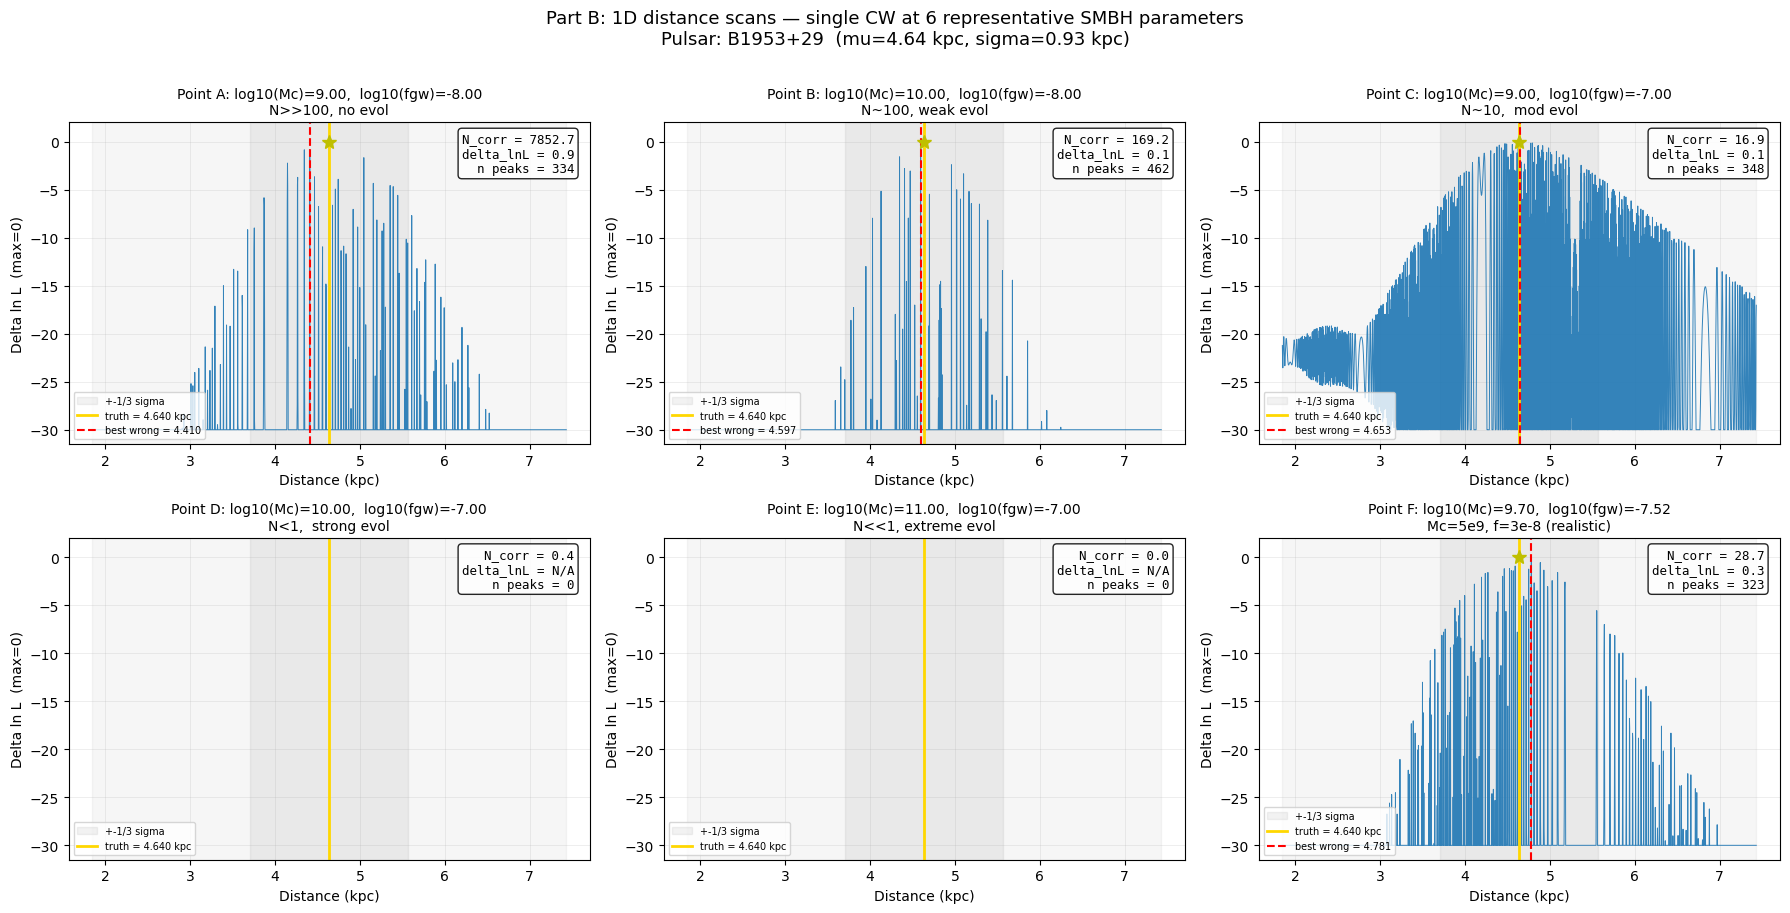

Saved: 01c_part_B_scans.pdf


In [ ]:
mu, sig = target_psr.pdist
clip_min = -30.0

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    f"Part B: 1D distance scans — single CW at 6 representative SMBH parameters\n"
    f"Pulsar: {target_psr.name}  (mu={mu:.2f} kpc, sigma={sig:.2f} kpc)",
    fontsize=13, y=1.01,
)

labels_order = ["A", "B", "C", "D", "E", "F"]
for ax, label in zip(axes.flat, labels_order):
    res = scan_results[label]
    sd, sl = res["scan_d"], res["scan_ll"]
    pk, dL = res["pk"], res["dL"]
    N_corr = res["N_corr"]
    delta  = res["delta_lnL"]

    sl_norm = sl - np.max(sl)
    sl_plot = np.clip(sl_norm, clip_min, 0)

    ax.plot(sd, sl_plot, "C0", lw=0.7, alpha=0.9)
    ax.axvspan(max(0.01, mu - 3*sig), mu + 3*sig, alpha=0.07, color="gray")
    ax.axvspan(max(0.01, mu - sig),   mu + sig,   alpha=0.10, color="gray",
               label="+-1/3 sigma")

    # Truth marker
    ax.axvline(mu, color="gold", lw=2.0, ls="-", label=f"truth = {mu:.3f} kpc")
    truth_norm = float(np.interp(mu, sd, sl_norm))
    ax.plot(mu, np.clip(truth_norm, clip_min, 0), "y*", ms=10, zorder=5)

    # Best wrong peak (if any)
    wrong_mask = np.abs(pk["peak_distances"] - mu) > 0.3 * dL
    if np.any(wrong_mask):
        best_wrong_d = pk["peak_distances"][wrong_mask][
            np.argmax(pk["peak_heights"][wrong_mask])
        ]
        ax.axvline(best_wrong_d, color="red", lw=1.5, ls="--",
                   label=f"best wrong = {best_wrong_d:.3f}")

    # Annotation
    delta_str = f"{delta:.1f}" if not np.isnan(delta) else "N/A"
    ann = (f"N_corr = {N_corr:.1f}\n"
           f"delta_lnL = {delta_str}\n"
           f"n peaks = {pk['n_peaks']}")
    ax.text(0.97, 0.97, ann,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

    ax.set_xlabel("Distance (kpc)", fontsize=10)
    ax.set_ylabel("Delta ln L  (max=0)", fontsize=10)
    ax.set_title(
        f"Point {label}: log10(Mc)={res['log10_Mc']:.2f},  "
        f"log10(fgw)={res['log10_fgw']:.2f}\n{res['desc']}",
        fontsize=10,
    )
    ax.set_ylim(clip_min * 1.05, 2.0)
    ax.legend(fontsize=7, loc="lower left")
    ax.grid(True, alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig("01c_part_B_scans.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_B_scans.pdf")


## Part C — Summary: validation points on N_corr heatmap

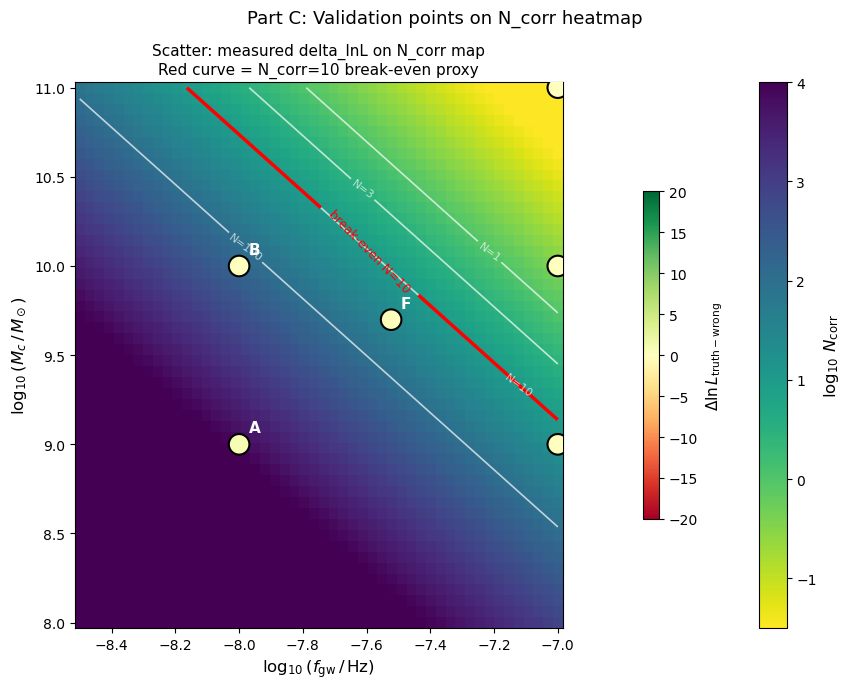

Saved: 01c_part_C_summary.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Part C: Validation points on N_corr heatmap", fontsize=13)

pcm = ax.pcolormesh(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                     cmap="viridis_r", shading="auto", vmin=-1.5, vmax=4.0)
cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label(r"$\log_{10}\,N_{\rm corr}$", fontsize=12)

# N_corr contours
nc_levels = [0.0, np.log10(3), 1.0, 2.0]
cs = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                 levels=nc_levels, colors="white", linewidths=1.2, alpha=0.7)
label_map = dict(zip(cs.levels, ["N=1", "N=3", "N=10", "N=100"]))
ax.clabel(cs, fmt=label_map, fontsize=8, inline=True)

# Scatter the 6 validation points, colored by measured delta_lnL
delta_vals = []
for label in ["A", "B", "C", "D", "E", "F"]:
    res = scan_results[label]
    d = res["delta_lnL"]
    delta_vals.append(d if not np.isnan(d) else 0.0)

delta_arr = np.array(delta_vals)
delta_finite = delta_arr[np.isfinite(delta_arr)]
if len(delta_finite) > 0:
    scale = max(20.0, np.nanmax(np.abs(delta_finite)))
else:
    scale = 20.0
norm_delta = mcolors.TwoSlopeNorm(vmin=-scale, vcenter=0.0, vmax=scale)

sc = ax.scatter(
    [scan_results[l]["log10_fgw"] for l in ["A","B","C","D","E","F"]],
    [scan_results[l]["log10_Mc"]  for l in ["A","B","C","D","E","F"]],
    c=delta_arr, cmap="RdYlGn", norm=norm_delta, s=220, zorder=5,
    edgecolors="k", linewidths=1.5,
)
cb2 = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.12)
cb2.set_label(r"$\Delta\ln L_{\rm truth-wrong}$", fontsize=11)

# Label each point
for label in ["A","B","C","D","E","F"]:
    res = scan_results[label]
    ax.text(res["log10_fgw"] + 0.03, res["log10_Mc"] + 0.05, label,
            fontsize=11, fontweight="bold", color="white",
            ha="left", va="bottom")

# Rough "break-even" curve: draw the N_corr contour that best separates
# delta_lnL > 10 from delta_lnL < 10.  Use the N_corr=10 contour as proxy.
cs_be = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                    levels=[1.0], colors=["red"], linestyles=["-"],
                    linewidths=[2.5])
ax.clabel(cs_be, fmt={1.0: "break-even N=10"}, fontsize=9, inline=True)

ax.set_xlabel(r"$\log_{10}(f_{\rm gw}\,/\,{\rm Hz})$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(M_c\,/\,M_\odot)$", fontsize=12)
ax.set_title(
    "Scatter: measured delta_lnL on N_corr map\n"
    "Red curve = N_corr=10 break-even proxy",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("01c_part_C_summary.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_C_summary.pdf")


## Part D — Better one-CW mode-breaking diagnostics

The raw distance scan is hard to read because the x-axis contains thousands of nearly periodic modes. The two more useful views are:

1. **Mode index**: convert distance to `(D - D_truth) / dL`, so adjacent monochromatic modes are separated by 1.
2. **Peak envelope**: plot only local maxima vs mode index. If evolution breaks the degeneracy, peak height should form an envelope centered on truth.

These plots use the likelihood scans already computed in Part B.


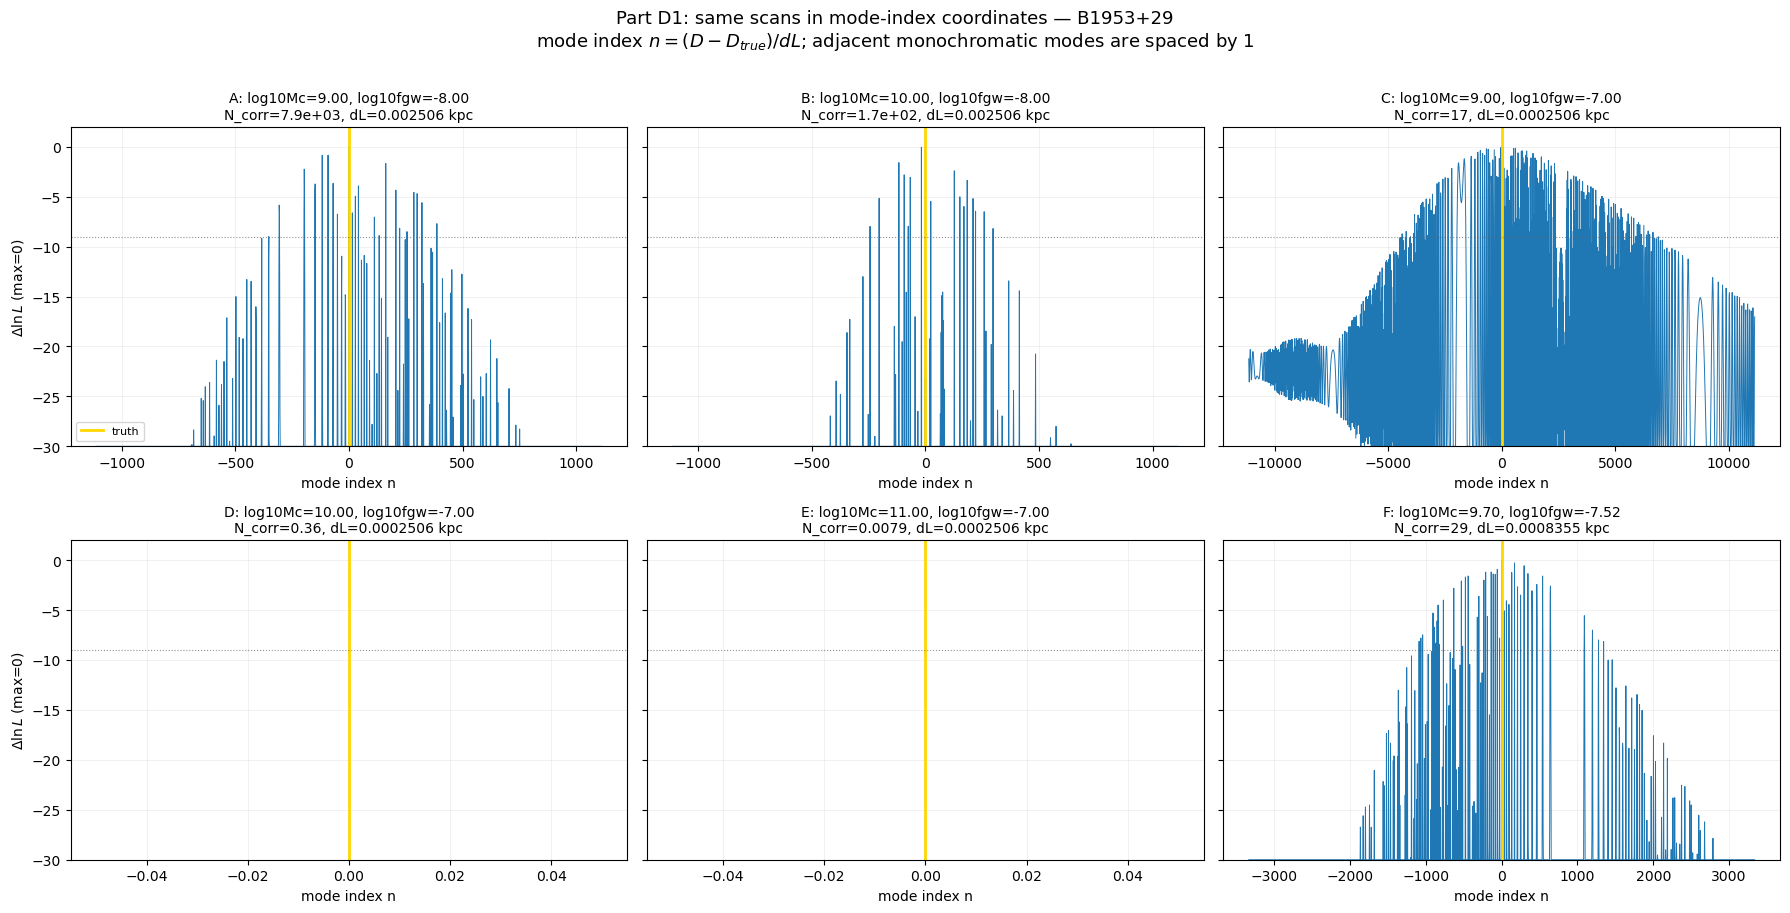

Saved: 01c_part_D1_mode_index_scans.pdf


In [ ]:
# Part D1: mode-index scan panels
mu, sig = target_psr.pdist
clip_min = -30.0
labels_order = ["A", "B", "C", "D", "E", "F"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
fig.suptitle(
    f"Part D1: same scans in mode-index coordinates — {target_psr.name}\n"
    r"mode index $n=(D-D_{true})/dL$; adjacent monochromatic modes are spaced by 1",
    fontsize=13, y=1.01,
)

for ax, label in zip(axes.flat, labels_order):
    res = scan_results[label]
    sd, sl, dL = res["scan_d"], res["scan_ll"], res["dL"]
    nmode = (sd - mu) / dL
    sl_norm = sl - np.max(sl)
    ax.plot(nmode, np.clip(sl_norm, clip_min, 0), "C0", lw=0.7)
    ax.axvline(0, color="gold", lw=2, label="truth")
    ax.axhline(-9, color="0.4", lw=0.8, ls=":", alpha=0.7)
    ax.set_title(
        f"{label}: log10Mc={res['log10_Mc']:.2f}, log10fgw={res['log10_fgw']:.2f}\n"
        f"N_corr={res['N_corr']:.2g}, dL={dL:.4g} kpc",
        fontsize=10,
    )
    ax.set_xlabel("mode index n")
    ax.grid(True, alpha=0.25, lw=0.5)
    ax.set_ylim(clip_min, 2)
    if ax is axes.flat[0]:
        ax.legend(fontsize=8, loc="lower left")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\Delta\ln L$ (max=0)")

plt.tight_layout()
plt.savefig("01c_part_D1_mode_index_scans.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_D1_mode_index_scans.pdf")


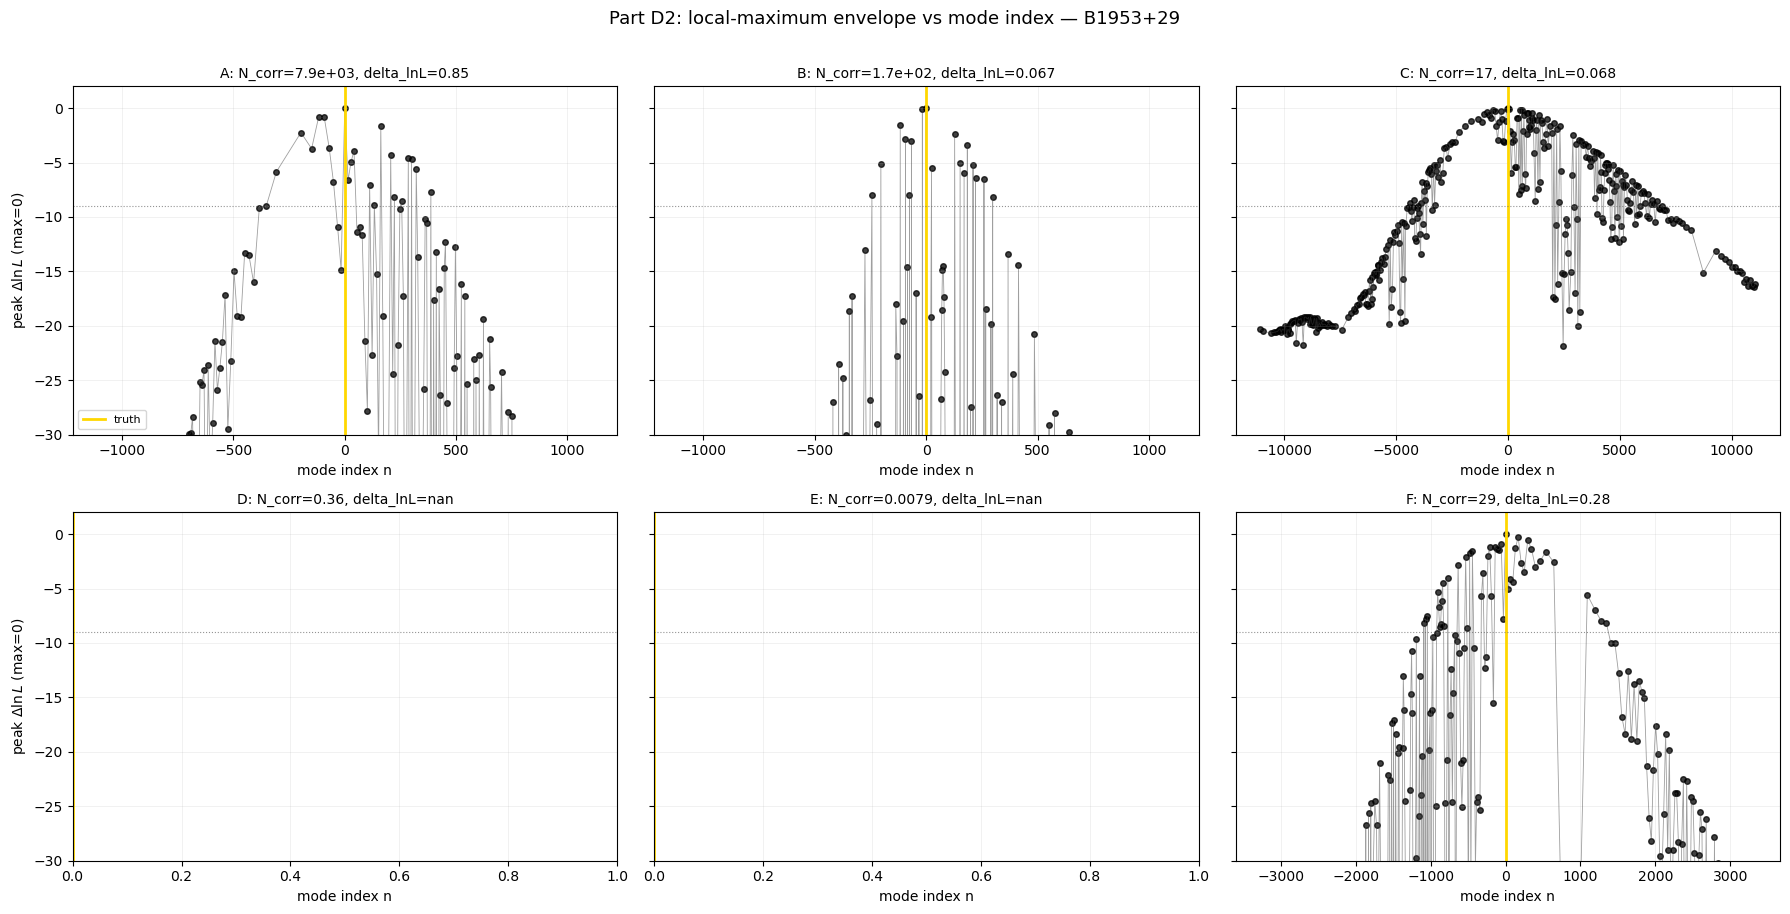

Saved: 01c_part_D2_peak_envelopes.pdf


In [ ]:
# Part D2: peak-envelope view
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
fig.suptitle(
    f"Part D2: local-maximum envelope vs mode index — {target_psr.name}",
    fontsize=13, y=1.01,
)

for ax, label in zip(axes.flat, labels_order):
    res = scan_results[label]
    pk, dL = res["pk"], res["dL"]
    if len(pk["peak_distances"]) > 0:
        mode_idx = (pk["peak_distances"] - mu) / dL
        peak_norm = pk["peak_heights"] - np.max(res["scan_ll"])
        ax.scatter(mode_idx, peak_norm, s=16, c="k", alpha=0.75)
        ax.plot(mode_idx, peak_norm, color="0.25", lw=0.6, alpha=0.5)
    ax.axvline(0, color="gold", lw=2, label="truth")
    ax.axhline(-9, color="0.4", lw=0.8, ls=":", alpha=0.7)
    ax.set_title(
        f"{label}: N_corr={res['N_corr']:.2g}, "
        f"delta_lnL={res['delta_lnL'] if np.isfinite(res['delta_lnL']) else np.nan:.2g}",
        fontsize=10,
    )
    ax.set_xlabel("mode index n")
    ax.grid(True, alpha=0.25, lw=0.5)
    ax.set_ylim(clip_min, 2)
    if ax is axes.flat[0]:
        ax.legend(fontsize=8, loc="lower left")
for ax in axes[:, 0]:
    ax.set_ylabel(r"peak $\Delta\ln L$ (max=0)")

plt.tight_layout()
plt.savefig("01c_part_D2_peak_envelopes.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_D2_peak_envelopes.pdf")


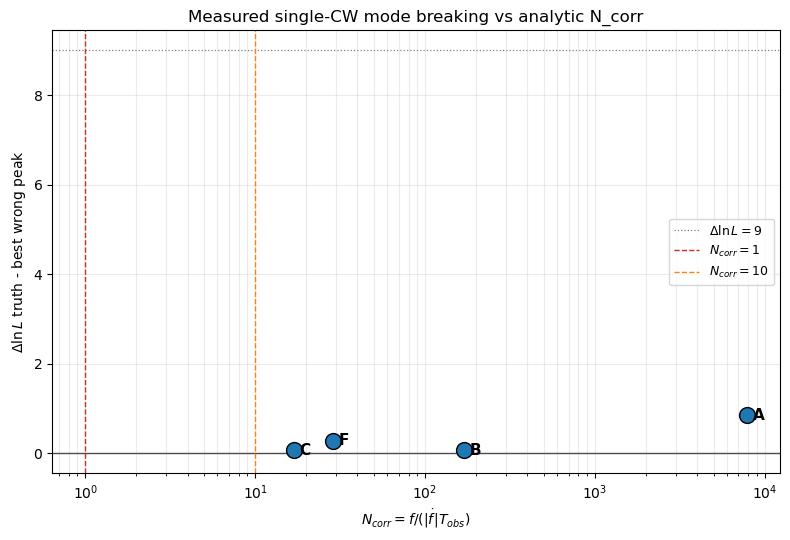

Saved: 01c_part_D3_delta_vs_Ncorr.pdf


In [ ]:
# Part D3: measured mode breaking vs N_corr
fig, ax = plt.subplots(figsize=(8, 5.5))
xs = np.array([scan_results[l]["N_corr"] for l in labels_order])
ys = np.array([scan_results[l]["delta_lnL"] for l in labels_order], dtype=float)

ax.axhline(0, color="0.3", lw=1.0)
ax.axhline(9, color="0.5", lw=0.9, ls=":", label=r"$\Delta\ln L=9$")
ax.axvline(1, color="C3", lw=1.0, ls="--", label=r"$N_{corr}=1$")
ax.axvline(10, color="C1", lw=1.0, ls="--", label=r"$N_{corr}=10$")
for label, x, y in zip(labels_order, xs, ys):
    ax.scatter(x, y, s=130, edgecolor="k", facecolor="C0", zorder=3)
    ax.text(x * 1.08, y, label, va="center", fontsize=11, fontweight="bold")
ax.set_xscale("log")
ax.set_xlabel(r"$N_{corr} = f/(|\dot f| T_{obs})$")
ax.set_ylabel(r"$\Delta\ln L$ truth - best wrong peak")
ax.set_title("Measured single-CW mode breaking vs analytic N_corr")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.savefig("01c_part_D3_delta_vs_Ncorr.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_D3_delta_vs_Ncorr.pdf")


## Part E — Optional measured phase diagram

This cell can run a small measured grid in `(M_c, f_gw)` and compute `delta_lnL` everywhere, instead of validating only six points. It is off by default because each point builds a new likelihood and JIT-compiles.


measured grid [0,0] logMc=8.50, logf=-8.30
measured grid [0,1] logMc=8.50, logf=-8.08
measured grid [0,2] logMc=8.50, logf=-7.87
measured grid [0,3] logMc=8.50, logf=-7.65
measured grid [0,4] logMc=8.50, logf=-7.43
measured grid [0,5] logMc=8.50, logf=-7.22
measured grid [0,6] logMc=8.50, logf=-7.00
measured grid [1,0] logMc=8.88, logf=-8.30
measured grid [1,1] logMc=8.88, logf=-8.08
measured grid [1,2] logMc=8.88, logf=-7.87
measured grid [1,3] logMc=8.88, logf=-7.65
measured grid [1,4] logMc=8.88, logf=-7.43
measured grid [1,5] logMc=8.88, logf=-7.22
measured grid [1,6] logMc=8.88, logf=-7.00
measured grid [2,0] logMc=9.27, logf=-8.30
measured grid [2,1] logMc=9.27, logf=-8.08
measured grid [2,2] logMc=9.27, logf=-7.87
measured grid [2,3] logMc=9.27, logf=-7.65
measured grid [2,4] logMc=9.27, logf=-7.43
measured grid [2,5] logMc=9.27, logf=-7.22
measured grid [2,6] logMc=9.27, logf=-7.00
measured grid [3,0] logMc=9.65, logf=-8.30
measured grid [3,1] logMc=9.65, logf=-8.08
measured gr

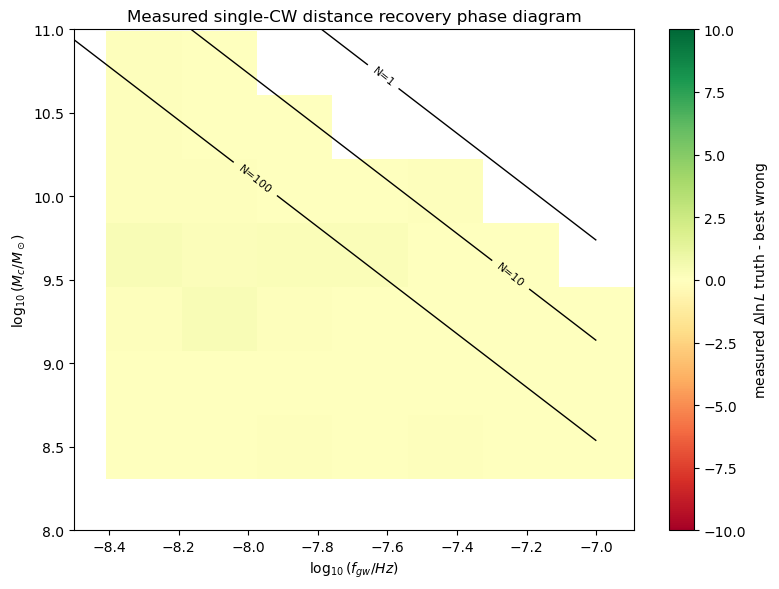

In [ ]:
RUN_MEASURED_GRID = False

if RUN_MEASURED_GRID:
    measured_Mc = np.linspace(8.5, 10.8, 7)
    measured_f = np.linspace(-8.3, -7.0, 7)
    measured_delta = np.full((len(measured_Mc), len(measured_f)), np.nan)
    measured_Ncorr = np.full_like(measured_delta, np.nan)

    for a, logMc in enumerate(measured_Mc):
        for b, logf in enumerate(measured_f):
            print(f"measured grid [{a},{b}] logMc={logMc:.2f}, logf={logf:.2f}")
            cw_p = dict(BASE_CW)
            cw_p["log10_mc"] = float(logMc)
            cw_p["log10_fgw"] = float(logf)

            Mc_g = MSUN_GEOM * 10**logMc
            fgw = 10**logf
            fdot = (96/5) * np.pi**(8/3) * Mc_g**(5/3) * fgw**(11/3)
            measured_Ncorr[a, b] = fgw / (abs(fdot) * TSPAN)

            residual_map, _ = inject_noisefree_cw(disco_psrs, [cw_p])
            logl_fn, param_keys, base_values = build_noisefree_likelihood(
                disco_psrs, residual_map, num_cw=1, cw_params_list=[cw_p]
            )
            _ = logl_fn(base_values)

            dL = compute_mode_spacing(
                cw_p["cos_gwtheta"], cw_p["gwphi"], cw_p["log10_fgw"], target_psr.pos
            )
            scan_min = max(0.01, mu - 3.0 * sig)
            scan_max = mu + 3.0 * sig
            prior_width = scan_max - scan_min
            n_pts = min(5000, max(500, int(12 * prior_width / dL))) if dL > 0 else 5000
            dist_key = f"{target_psr.name}_cw_p_dist"
            scan_d, scan_ll = scan_pulsar_distance(
                logl_fn, base_values, param_keys, dist_key,
                scan_min, scan_max, n_pts, required_points=[mu]
            )
            pk = analyze_peaks(scan_d, scan_ll, mu, mode_spacing=dL)
            measured_delta[a, b] = pk["delta_lnL_truth_vs_best_wrong"]

    fig, ax = plt.subplots(figsize=(8, 6))
    scale = np.nanmax(np.abs(measured_delta))
    scale = max(scale, 10.0) if np.isfinite(scale) else 10.0
    norm = mcolors.TwoSlopeNorm(vmin=-scale, vcenter=0.0, vmax=scale)
    pcm = ax.pcolormesh(measured_f, measured_Mc, measured_delta, cmap="RdYlGn", norm=norm, shading="auto")
    plt.colorbar(pcm, ax=ax, label=r"measured $\Delta\ln L$ truth - best wrong")
    cs = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                    levels=[0, 1, 2], colors="k", linewidths=1.0)
    ax.clabel(cs, fmt={0:"N=1", 1:"N=10", 2:"N=100"}, fontsize=8)
    ax.set_xlabel(r"$\log_{10}(f_{gw}/Hz)$")
    ax.set_ylabel(r"$\log_{10}(M_c/M_\odot)$")
    ax.set_title("Measured single-CW distance recovery phase diagram")
    plt.tight_layout()
    plt.savefig("01c_part_E_measured_phase_diagram.pdf", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("RUN_MEASURED_GRID=False. Set True to compute measured delta_lnL grid.")


## Part F — Literature-motivated SMBHB population overlay

This section now uses a simple semi-empirical SMBHB population, rather than an arbitrary toy draw. It is still **not** a full `holodeck`/population-synthesis run, but its ingredients follow common PTA SMBHB modeling choices:

- **PTA SMBHB population context**: NANOGrav 15 yr SMBHB population analysis shows astrophysically motivated SMBHB populations can reproduce the observed GWB, and stresses binary evolution modeling ([Agazie et al. 2023, arXiv:2306.16220](https://arxiv.org/abs/2306.16220)).
- **Individual CW context**: loudest SMBHBs may be individually detectable, but current 15 yr all-sky searches found no compelling CW candidate ([Agazie et al. 2023, arXiv:2306.16222](https://arxiv.org/abs/2306.16222)); targeted AGN searches are also now being pursued ([NANOGrav targeted searches, arXiv:2508.16534](https://arxiv.org/abs/2508.16534)).
- **SMBHB population construction**: sample massive galaxies from a Schechter-like stellar mass function, weight by a redshift- and mass-dependent merger rate, draw merger mass ratios, then map bulge mass to SMBH mass using the McConnell & Ma black-hole/bulge scaling relation.
- **Frequency residence**: for circular GW-driven binaries, residence weighting gives `dN/df ∝ f^(-11/3)` or `dN/dlnf ∝ f^(-8/3)`, so sources pile up at low PTA frequencies.

The output remains a **relative density** over `(M_c,z, f_gw)`, useful for asking where plausible PTA-band binaries sit relative to `N_corr`, not an absolute event-rate prediction.


Because an absolute `h0 > 1e-15` cut can select zero sources in a finite semi-empirical draw, the second population plot uses the **loudest strain tail inside the plotted window** by default. The absolute-threshold summary table remains below.


**Important caveat:** the local Holodeck package includes an older Mingarelli-style continuous-population `.npz`, but that file does **not** document a GW-frequency axis. We therefore do **not** use it for the main overlay by default. The default overlay below is the explicit semi-empirical model, where every plotted quantity (`M_c,z`, `f_gw`, `h0`, `N_corr`) is generated transparently in this notebook.



In [ ]:
# SMBHB population context.
# Default uses explicit semi-empirical draw. The bundled Holodeck NPZ path is
# disabled because its frequency axis is not documented.
rng = np.random.default_rng(12345)
H0 = 70.0                         # km/s/Mpc
OMEGA_M = 0.3
OMEGA_L = 0.7
MPC_M = 3.0856775814913673e22
C_KM_S = 299792.458
HOLODECK_SAMPLE = "../CW_lnL_check/holodeck_bundled_population_sample.npz"
USE_EXPERIMENTAL_HOLODECK_BUNDLED = False

if USE_EXPERIMENTAL_HOLODECK_BUNDLED and Path(HOLODECK_SAMPLE).exists():
    pop = np.load(HOLODECK_SAMPLE, allow_pickle=True)
    population_label = str(pop["model_name"])
    z = pop["z"]
    Mc_z = pop["mc_z"]
    fgw_pop = pop["fgw"]
    h0_pop = pop["h0"]
    Ncorr_pop = pop["ncorr"]
    log10_Mc_z = np.log10(Mc_z)
    log10_fgw_pop = np.log10(fgw_pop)

    # Diagnostics only: recompute D_L for printed percentiles.
    z_grid = np.linspace(1e-5, max(3.0, float(np.nanmax(z)) + 0.01), 5000)
    Ez = np.sqrt(OMEGA_M * (1 + z_grid)**3 + OMEGA_L)
    dz = np.diff(z_grid)
    Dc = np.zeros_like(z_grid)
    Dc[1:] = (C_KM_S / H0) * np.cumsum(0.5 * ((1/Ez)[1:] + (1/Ez)[:-1]) * dz)
    DL_mpc = (1 + np.maximum(z, 1e-5)) * np.interp(np.maximum(z, 1e-5), z_grid, Dc)

    print(f"Loaded EXPERIMENTAL Holodeck bundled population sample: {HOLODECK_SAMPLE}")
    print(f"Sample size: {len(fgw_pop):,}")
    print("Model:", population_label)
    print("WARNING: frequency axis is not documented in the source Holodeck file.")
    print("Frequency note:", str(pop["frequency_assumption"]))
else:
    population_label = "semi-empirical fallback population"
    N_POP = 250_000

    # Cosmology helpers
    z_grid = np.linspace(1e-4, 2.5, 5000)
    Ez = np.sqrt(OMEGA_M * (1 + z_grid)**3 + OMEGA_L)
    dz = np.diff(z_grid)
    integrand = 1.0 / Ez
    Dc = np.zeros_like(z_grid)
    Dc[1:] = (C_KM_S / H0) * np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    dV_dz = 4.0 * np.pi * (C_KM_S / H0) * Dc**2 / Ez

    # Merger-rate redshift evolution proxy: pair fractions increase with redshift.
    # Observer-frame rate includes (1+z)^-1 time-dilation.
    gamma_z = 1.5
    pdf_z = dV_dz * (1 + z_grid)**gamma_z / (1 + z_grid)
    cdf_z = np.cumsum(0.5 * (pdf_z[1:] + pdf_z[:-1]) * dz)
    cdf_z = np.concatenate([[0.0], cdf_z])
    cdf_z = cdf_z / cdf_z[-1]
    z = np.interp(rng.random(N_POP), cdf_z, z_grid)
    Dc_samp = np.interp(z, z_grid, Dc)
    DL_mpc = (1 + z) * Dc_samp
    DL_sec = DL_mpc * MPC_M / C_LIGHT

    def sample_primary_logMstar(n):
        logM_min, logM_max = 10.0, 12.25
        logM_star = 10.85
        alpha_s = -1.25
        beta_merger_mass = 0.3
        samples = []
        grid = np.linspace(logM_min, logM_max, 2000)
        x = 10 ** (grid - logM_star)
        w = x ** (alpha_s + 1.0) * np.exp(-x) * (10 ** (grid - 11.0)) ** beta_merger_mass
        wmax = np.max(w)
        while len(samples) < n:
            batch = max(20000, n - len(samples))
            cand = rng.uniform(logM_min, logM_max, batch)
            x_c = 10 ** (cand - logM_star)
            w_c = x_c ** (alpha_s + 1.0) * np.exp(-x_c) * (10 ** (cand - 11.0)) ** beta_merger_mass
            keep = rng.random(batch) < (w_c / wmax)
            samples.extend(cand[keep].tolist())
        return np.array(samples[:n])

    logMstar1 = sample_primary_logMstar(N_POP)
    Mstar1 = 10 ** logMstar1
    q_min = 0.1
    q_slope = -0.3
    u = rng.random(N_POP)
    q_star = (u * (1.0 ** (q_slope + 1) - q_min ** (q_slope + 1)) + q_min ** (q_slope + 1)) ** (1.0 / (q_slope + 1))
    Mstar2 = q_star * Mstar1
    fbulge1 = np.clip(rng.normal(0.75, 0.18, N_POP), 0.25, 1.0)
    fbulge2 = np.clip(rng.normal(0.65, 0.22, N_POP), 0.15, 1.0)
    Mbulge1 = fbulge1 * Mstar1
    Mbulge2 = fbulge2 * Mstar2
    scatter_bh = 0.34
    logMBH1 = 8.46 + 1.05 * (np.log10(Mbulge1) - 11.0) + rng.normal(0.0, scatter_bh, N_POP)
    logMBH2 = 8.46 + 1.05 * (np.log10(Mbulge2) - 11.0) + rng.normal(0.0, scatter_bh, N_POP)
    MBH1 = 10 ** logMBH1
    MBH2 = 10 ** logMBH2
    m_hi = np.maximum(MBH1, MBH2)
    m_lo = np.minimum(MBH1, MBH2)
    Mtot = m_hi + m_lo
    Mc_src = (m_hi * m_lo) ** (3.0 / 5.0) / Mtot ** (1.0 / 5.0)
    Mc_z = Mc_src * (1 + z)
    log10_Mc_z = np.log10(Mc_z)
    Mc_geom_z = MSUN_GEOM * Mc_z

    fmin = 1.0 / TSPAN
    fmax = 1e-7
    alpha_f = -11.0 / 3.0
    u = rng.random(N_POP)
    fgw_pop = (u * (fmax**(alpha_f + 1) - fmin**(alpha_f + 1)) + fmin**(alpha_f + 1)) ** (1.0 / (alpha_f + 1))
    log10_fgw_pop = np.log10(fgw_pop)
    fdot_pop = (96.0/5.0) * np.pi**(8.0/3.0) * Mc_geom_z**(5.0/3.0) * fgw_pop**(11.0/3.0)
    Ncorr_pop = fgw_pop / (np.abs(fdot_pop) * TSPAN)
    h0_pop = 4.0 * Mc_geom_z**(5.0/3.0) * (np.pi * fgw_pop)**(2.0/3.0) / DL_sec
    print(f"Using fallback semi-empirical population size: {N_POP:,}")

# Only show masses/frequencies covered by Part A map.
in_map = (
    (log10_fgw_pop >= log10_fgw_arr.min()) & (log10_fgw_pop <= log10_fgw_arr.max()) &
    (log10_Mc_z >= log10_Mc_arr.min()) & (log10_Mc_z <= log10_Mc_arr.max()) &
    np.isfinite(h0_pop) & np.isfinite(Ncorr_pop)
)

print(f"In plotted (Mc_z, fgw) window: {np.sum(in_map):,} ({np.mean(in_map):.2%})")
print(f"median log10(Mc_z/Msun) = {np.median(log10_Mc_z[np.isfinite(log10_Mc_z)]):.2f}")
print(f"median log10(fgw/Hz)    = {np.median(log10_fgw_pop[np.isfinite(log10_fgw_pop)]):.2f}")
for thr in [3e-16, 1e-15, 3e-15]:
    m = (h0_pop > thr) & in_map
    frac = np.mean(m)
    med_N = np.nanmedian(Ncorr_pop[m]) if np.any(m) else np.nan
    frac_break = np.mean(Ncorr_pop[m] < 10) if np.any(m) else np.nan
    print(f"h0>{thr:.0e} in map: {m.sum():7d} ({frac:.3%}); median Ncorr={med_N:.2g}; frac Ncorr<10={frac_break:.2%}")





Semi-empirical population size: 250,000
In plotted (Mc_z, fgw) window: 31,536 (12.61%)
median log10(Mc_z/Msun) = 7.84
median log10(fgw/Hz)    = -8.56
h0>3e-16 in map:      17 (0.007%); median Ncorr=4.8e+03; frac Ncorr<10=0.00%
h0>1e-15 in map:       0 (0.000%); median Ncorr=nan; frac Ncorr<10=nan%
h0>3e-15 in map:       0 (0.000%); median Ncorr=nan; frac Ncorr<10=nan%


### Part F diagnostics — why the plotted/high-strain population is small

The semi-empirical **number** population is dominated by low-frequency, moderate-mass, high-redshift binaries. That is expected from residence-time weighting and cosmic volume. Individually detectable CWs are instead an extreme loud tail, biased toward nearby, massive, high-frequency systems.

So there are two different questions:

1. **Where do most SMBHBs live?** Use number-density contours.
2. **Where are sources likely to matter for PTA CW searches?** Use a loud-tail or strain-weighted density proxy.

This cell prints the distribution diagnostics and adds a strain-squared weighted density plot as a crude CW-detectability proxy.


In [ ]:
# Population diagnostics and a strain-weighted density proxy.
percentiles = [1, 5, 16, 50, 84, 95, 99, 99.9]
print("Population percentiles (full draw):")
for name, arr in [
    ("z", z),
    ("D_L [Mpc]", DL_mpc),
    ("log10 Mc,z", log10_Mc_z),
    ("log10 fgw", log10_fgw_pop),
    ("log10 h0", np.log10(h0_pop)),
    ("log10 Ncorr", np.log10(Ncorr_pop)),
]:
    vals = np.nanpercentile(arr, percentiles)
    print(f"  {name:12s}: " + "  ".join(f"p{p:g}={v:.2f}" for p, v in zip(percentiles, vals)))

print("\nMain assumptions suppressing h0>1e-15 counts:")
print("  1. GW residence weighting puts most systems at fgw just above 1/Tspan.")
print("  2. Cosmic-volume weighting puts most systems at z ~ 1-2, i.e. large D_L.")
print("  3. The stellar-mass-function draw makes log10(Mc,z)>9.5 rare.")
print("  4. h0>1e-15 is a very loud individual-CW cut, not a typical population cut.")

# Weighted density: if PTA CW sensitivity scales roughly with strain, h0^2 is a
# useful first-order proxy for contribution to matched-filter SNR^2.
xrange = [log10_fgw_arr.min(), log10_fgw_arr.max()]
yrange = [log10_Mc_arr.min(), log10_Mc_arr.max()]
weights = np.zeros_like(h0_pop)
weights[in_map] = h0_pop[in_map] ** 2
H_w, xedges_w, yedges_w = np.histogram2d(
    log10_fgw_pop[in_map], log10_Mc_z[in_map], bins=85, range=[xrange, yrange],
    weights=weights[in_map],
)
dx_w = np.diff(xedges_w)[0]
dy_w = np.diff(yedges_w)[0]
weighted_density = H_w.T / (np.sum(weights[in_map]) * dx_w * dy_w)
weighted_density = np.ma.masked_where(weighted_density <= 0, weighted_density)

fig, ax = plt.subplots(figsize=(9, 7))
pcm = ax.pcolormesh(
    log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
    cmap="viridis_r", shading="auto", vmin=-1.5, vmax=4.0,
)
cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label(r"$\log_{10}N_{corr}$", fontsize=11)

cs_n = ax.contour(log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
                  levels=[0, 1, 2, 3], colors="white", linewidths=1.15)
ax.clabel(cs_n, fmt={0:"N=1", 1:"N=10", 2:"N=100", 3:"N=1000"}, fontsize=8)

xcent_w = 0.5 * (xedges_w[:-1] + xedges_w[1:])
ycent_w = 0.5 * (yedges_w[:-1] + yedges_w[1:])
pos = np.asarray(weighted_density.compressed())
levels_w = np.nanpercentile(pos, [70, 85, 95, 99]) if len(pos) else []
if len(levels_w):
    cs_w = ax.contour(xcent_w, ycent_w, weighted_density, levels=np.unique(levels_w),
                      colors="magenta", linewidths=1.8)
    fmt = {lev: f"{lev:.2g}/dex$^2$" for lev in cs_w.levels}
    ax.clabel(cs_w, fmt=fmt, fontsize=8)

ax.scatter(
    [scan_results[l]["log10_fgw"] for l in labels_order],
    [scan_results[l]["log10_Mc"] for l in labels_order],
    s=110, facecolor="none", edgecolor="yellow", linewidth=2.0,
    label="validation points", zorder=5,
)
ax.text(0.03, 0.97,
        "magenta contours:\nh0^2-weighted density\n(proxy for CW SNR^2 contribution)",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.88))
ax.set_xlabel(r"$\log_{10}(f_{gw}/Hz)$")
ax.set_ylabel(r"$\log_{10}(M_{c,z}/M_\odot)$")
ax.set_title("Part F3: Strain-weighted population density on Ncorr heatmap")
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig("01c_part_F3_strain_weighted_density.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_F3_strain_weighted_density.pdf")


Loud-tail strain cut in plotted window: h0 >= 8.91e-17 (top 0.5%)


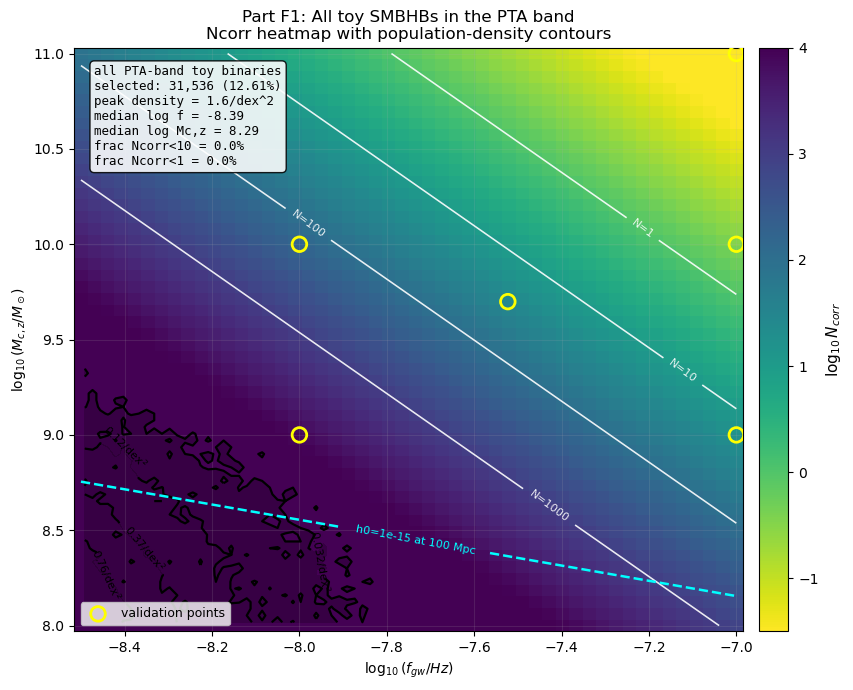

Saved: 01c_part_F1_population_on_Ncorr_all.pdf


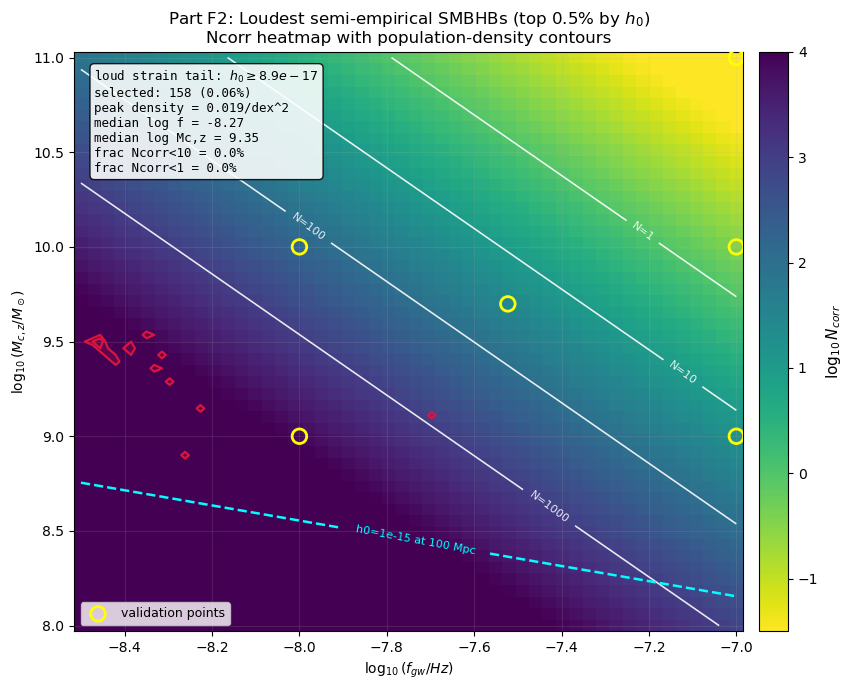

Saved: 01c_part_F2_population_on_Ncorr_detectable.pdf


In [ ]:
# Population density overlays on N_corr heatmaps.
# Background color = log10(N_corr). Population density is overlaid as labeled
# contours in probability per dex^2, so the mode-breaking heatmap remains visible.

xrange = [log10_fgw_arr.min(), log10_fgw_arr.max()]
yrange = [log10_Mc_arr.min(), log10_Mc_arr.max()]
bins = 85

def population_density_grid(x, y, mask=None, bins=85):
    if mask is None:
        mask = np.ones_like(x, dtype=bool)
    H, xedges, yedges = np.histogram2d(
        x[mask], y[mask], bins=bins, range=[xrange, yrange]
    )
    dx = np.diff(xedges)[0]
    dy = np.diff(yedges)[0]
    # Probability density per dex^2, normalized to the full toy population.
    density = H / (len(x) * dx * dy)
    xcent = 0.5 * (xedges[:-1] + xedges[1:])
    ycent = 0.5 * (yedges[:-1] + yedges[1:])
    return density.T, xcent, ycent


def nice_density_levels(density):
    positive = density[np.isfinite(density) & (density > 0)]
    if len(positive) == 0:
        return []
    qs = np.nanpercentile(positive, [50, 75, 90, 97])
    levels = np.unique(qs)
    return levels[levels > 0]


def plot_population_on_heatmap(mask, title, fname, contour_color, detected_label):
    density, xcent, ycent = population_density_grid(
        log10_fgw_pop, log10_Mc_z, mask=mask, bins=bins
    )
    levels = nice_density_levels(density)

    fig, ax = plt.subplots(figsize=(9, 7))
    pcm = ax.pcolormesh(
        log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
        cmap="viridis_r", shading="auto", vmin=-1.5, vmax=4.0,
    )
    cb = plt.colorbar(pcm, ax=ax, pad=0.02)
    cb.set_label(r"$\log_{10}N_{corr}$", fontsize=11)

    # N_corr contours for exact thresholds.
    cs_n = ax.contour(
        log10_fgw_arr, log10_Mc_arr, np.log10(N_corr_grid),
        levels=[0, 1, 2, 3], colors="white", linewidths=1.15, alpha=0.9,
    )
    ax.clabel(cs_n, fmt={0:"N=1", 1:"N=10", 2:"N=100", 3:"N=1000"}, fontsize=8)

    # Density contours. Labels are probability per dex^2.
    if len(levels) > 0:
        cf = ax.contourf(
            xcent, ycent, density,
            levels=np.r_[levels, density.max() * 1.001],
            colors=[contour_color], alpha=0.18,
        )
        cs_d = ax.contour(
            xcent, ycent, density,
            levels=levels, colors=contour_color, linewidths=1.6,
        )
        fmt = {lev: f"{lev:.2g}/dex$^2$" for lev in cs_d.levels}
        ax.clabel(cs_d, fmt=fmt, fontsize=8, inline=True)

    # Strain reference and validation points.
    cs_h = ax.contour(
        log10_fgw_arr, log10_Mc_arr, np.log10(hc_grid),
        levels=[-15], colors="cyan", linewidths=1.8, linestyles="--",
    )
    ax.clabel(cs_h, fmt={-15:"h0=1e-15 at 100 Mpc"}, fontsize=8)

    # ax.scatter(
    #     [scan_results[l]["log10_fgw"] for l in labels_order],
    #     [scan_results[l]["log10_Mc"] for l in labels_order],
    #     s=110, facecolor="none", edgecolor="yellow", linewidth=2.0,
    #     label="validation points", zorder=5,
    # )

    n_sel = int(np.sum(mask))
    frac_sel = n_sel / len(mask)
    if n_sel > 0:
        frac_n10 = np.mean(Ncorr_pop[mask] < 10)
        frac_n1 = np.mean(Ncorr_pop[mask] < 1)
        med_logf = np.median(log10_fgw_pop[mask])
        med_logmc = np.median(log10_Mc_z[mask])
        peak_density = float(np.nanmax(density))
        ann = (
            f"{detected_label}\n"
            f"selected: {n_sel:,} ({frac_sel:.2%})\n"
            f"peak density = {peak_density:.2g}/dex^2\n"
            f"median log f = {med_logf:.2f}\n"
            f"median log Mc,z = {med_logmc:.2f}\n"
            f"frac Ncorr<10 = {frac_n10:.1%}\n"
            f"frac Ncorr<1 = {frac_n1:.1%}"
        )
    else:
        ann = f"{detected_label}\nselected: 0"
    ax.text(
        0.03, 0.97, ann, transform=ax.transAxes,
        va="top", ha="left", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.88),
    )

    ax.set_xlabel(r"$\log_{10}(f_{gw}/Hz)$")
    ax.set_ylabel(r"$\log_{10}(M_{c,z}/M_\odot)$")
    ax.set_title(title)
    ax.legend(fontsize=9, loc="lower left")
    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {fname}")

all_mask = in_map
LOUD_PERCENTILE = 99.5
loud_cut = np.nanpercentile(h0_pop[in_map], LOUD_PERCENTILE)
det_mask = (h0_pop >= loud_cut) & in_map
print(f"Loud-tail strain cut in plotted window: h0 >= {loud_cut:.2e} (top {100-LOUD_PERCENTILE:.1f}%)")

plot_population_on_heatmap(
    all_mask,
    "Part F1: All toy SMBHBs in the PTA band\nNcorr heatmap with population-density contours",
    "01c_part_F1_population_on_Ncorr_all.pdf",
    "black",
    "all PTA-band toy binaries",
)

plot_population_on_heatmap(
    det_mask,
    f"Part F2: Loudest semi-empirical SMBHBs (top {100-LOUD_PERCENTILE:.1f}% by $h_0$)\nNcorr heatmap with population-density contours",
    "01c_part_F2_population_on_Ncorr_detectable.pdf",
    "crimson",
    rf"loud strain tail: $h_0 \geq {loud_cut:.1e}$",
)


    h0 cut         N    frac pop    frac N<1    frac N<10   med logMc_z   med logf
----------------------------------------------------------------------------------
   1.0e-16     49593     24.796%       0.00%        0.04%          9.59      -8.55
   3.0e-16     26408     13.204%       0.01%        0.08%          9.81      -8.54
   1.0e-15     10423      5.212%       0.02%        0.20%         10.05      -8.53
   3.0e-15      2949      1.474%       0.07%        0.61%         10.27      -8.51
   1.0e-14       443      0.222%       0.23%        2.03%         10.50      -8.49


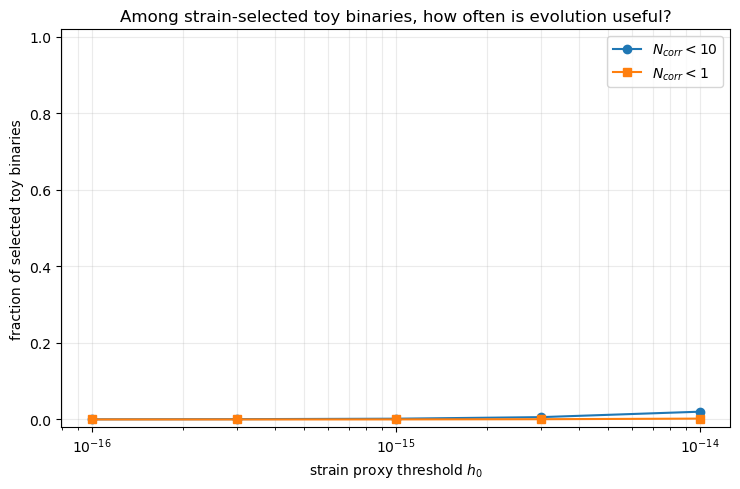

Saved: 01c_part_F_population_summary.pdf


In [ ]:
# Compact population summary: detectability vs mode-breaking cuts
thresholds = np.array([1e-16, 3e-16, 1e-15, 3e-15, 1e-14])
rows = []
for thr in thresholds:
    m = (h0_pop > thr) & in_map
    rows.append({
        "thr": thr,
        "n": int(np.sum(m)),
        "frac": float(np.mean(m)),
        "frac_N_lt_1": float(np.mean(Ncorr_pop[m] < 1)) if np.any(m) else np.nan,
        "frac_N_lt_10": float(np.mean(Ncorr_pop[m] < 10)) if np.any(m) else np.nan,
        "median_logMc_z": float(np.median(log10_Mc_z[m])) if np.any(m) else np.nan,
        "median_logf": float(np.median(log10_fgw_pop[m])) if np.any(m) else np.nan,
    })

print(f"{'h0 cut':>10}  {'N':>8}  {'frac pop':>10}  {'frac N<1':>10}  {'frac N<10':>11}  {'med logMc_z':>12}  {'med logf':>9}")
print("-" * 82)
for r in rows:
    print(f"{r['thr']:10.1e}  {r['n']:8d}  {r['frac']:10.3%}  {r['frac_N_lt_1']:10.2%}  {r['frac_N_lt_10']:11.2%}  {r['median_logMc_z']:12.2f}  {r['median_logf']:9.2f}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(thresholds, [r["frac_N_lt_10"] for r in rows], "o-", label=r"$N_{corr}<10$")
ax.plot(thresholds, [r["frac_N_lt_1"] for r in rows], "s-", label=r"$N_{corr}<1$")
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel(r"strain proxy threshold $h_0$")
ax.set_ylabel("fraction of selected toy binaries")
ax.set_title("Among strain-selected toy binaries, how often is evolution useful?")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig("01c_part_F_population_summary.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01c_part_F_population_summary.pdf")
